<a href="https://colab.research.google.com/github/thanhtam160603/CLARANS-Clustering-Analysis/blob/main/DataMining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Kết nối Google Drive
from google.colab import drive
drive.mount('/content/gdrive', force_remount = True)
folder = '/content/gdrive/My Drive/Colab Notebooks/kpdlFinal'

Mounted at /content/gdrive


## **Tiền xử lý dữ liệu**

In [ ]:
## Thư viện
import matplotlib.pyplot     as plt
import numpy                 as np
import pandas                as pd
import scipy                 as scp
import seaborn               as sbn
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import Binarizer, PolynomialFeatures, MinMaxScaler, StandardScaler
from sklearn.preprocessing   import LabelEncoder, OneHotEncoder

In [ ]:
## Đếm số dòng chứa NA (None, NaN) của mỗi cột
df = pd.read_csv(folder + '/test1.csv')
print('*** Số lượng giá trị bị thiếu của các cột:')
print(len(df) - df.count())

*** Số lượng giá trị bị thiếu của các cột:
id               0
battery_power    3
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        2
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
dtype: int64


In [ ]:
print('Số lượng giá trị bị thiếu của cột [battery_power]:', len(df[df['battery_power'].isnull()]))
print('Số lượng giá trị bị thiếu của cột [mobile_wt]:', len(df[df['mobile_wt'].isnull()]))
print("\n",df[['battery_power','mobile_wt']].head(10))

Số lượng giá trị bị thiếu của cột [battery_power]: 3
Số lượng giá trị bị thiếu của cột [mobile_wt]: 2

    battery_power  mobile_wt
0         1043.0      193.0
1          841.0      191.0
2         1807.0        NaN
3         1546.0       96.0
4         1434.0      108.0
5         1464.0      198.0
6            NaN      156.0
7          833.0      111.0
8         1111.0      101.0
9         1520.0      171.0


In [ ]:
df          = pd.read_csv(folder + '/test1.csv')
value       = round(df['battery_power'].mean())## Thay thế bằng giá trị xác định
df['battery_power'] = df['battery_power'].fillna(value)
df['mobile_wt'] = df.mobile_wt.interpolate()## Thay thế bằng phương pháp nội suy tuyến tính
print(df[['battery_power','mobile_wt']].head(10))
df.to_csv(folder + '/test1.csv',index=False)

   battery_power  mobile_wt
0         1043.0      193.0
1          841.0      191.0
2         1807.0      143.5
3         1546.0       96.0
4         1434.0      108.0
5         1464.0      198.0
6         1247.0      156.0
7          833.0      111.0
8         1111.0      101.0
9         1520.0      171.0


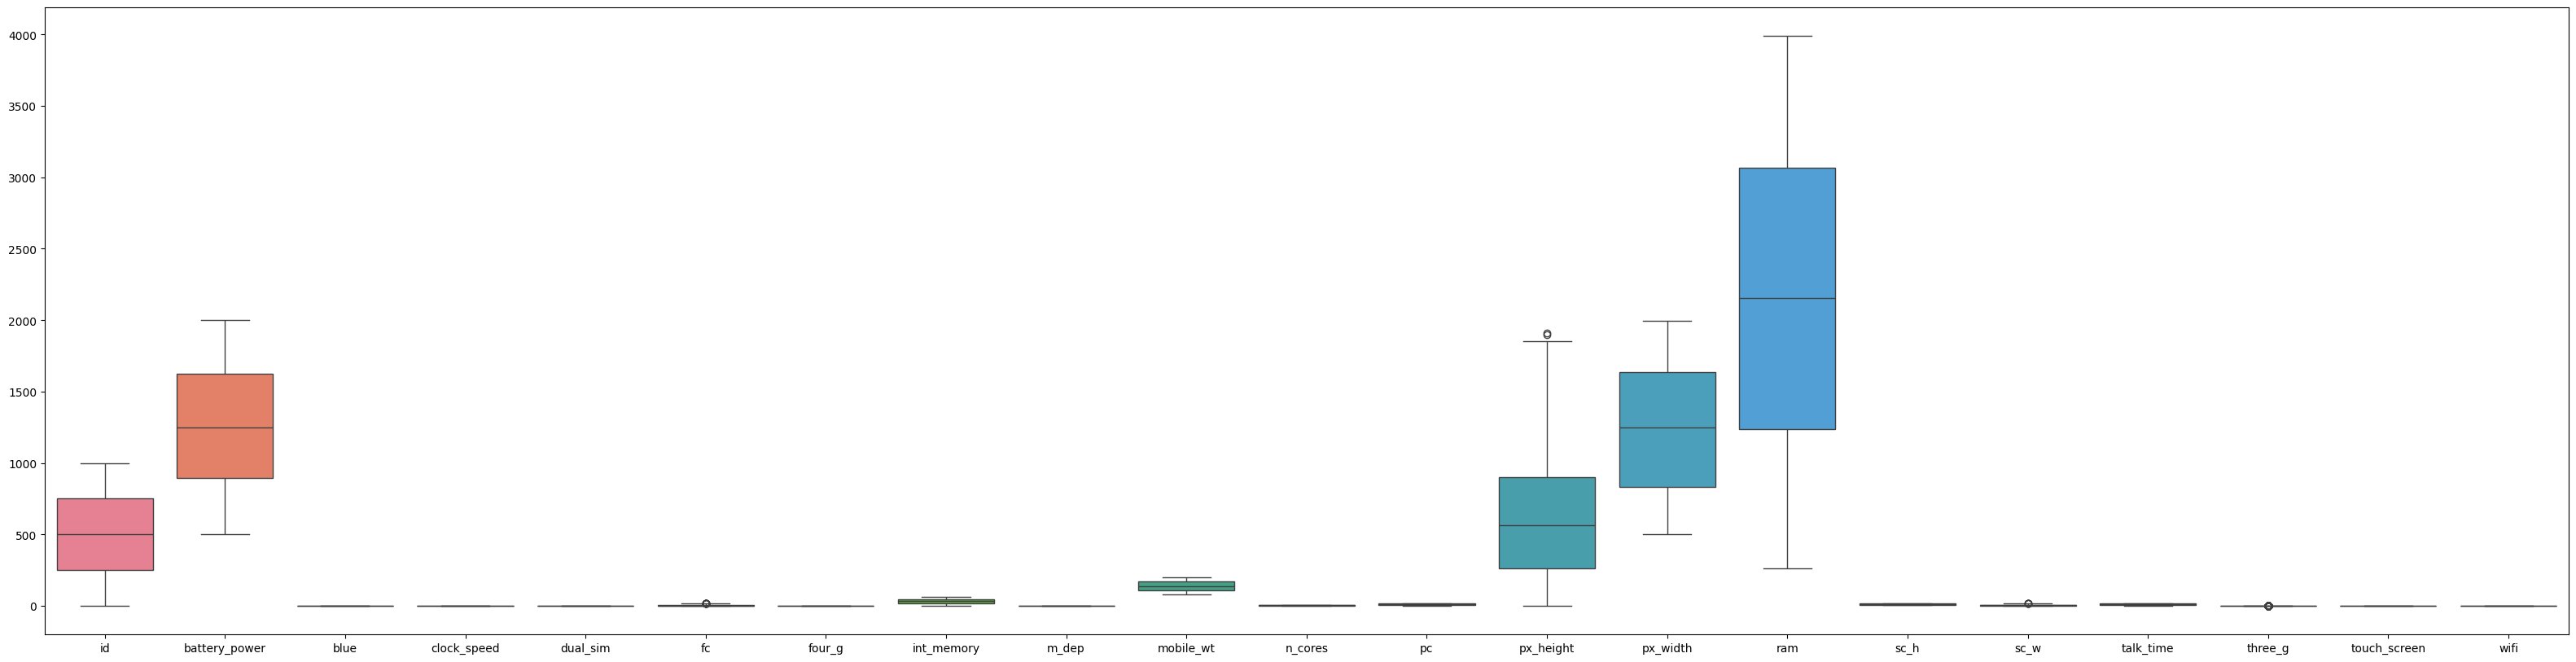

In [ ]:
df = pd.read_csv(folder + '/test1.csv')
plt.figure(figsize = (40, 10))
sbn.boxplot(df)

plt.show()

In [ ]:
df = pd.read_csv(folder + '/test1.csv')
data_z = scp.stats.zscore(df.battery_power, ddof = 1)
radius = 3

outliers = data_z[[abs(n) > radius for n in data_z]]
indexes  = [data_z.tolist().index(i) for i in outliers]
print("Chỉ số của outliers:", indexes)
print("Giá trị outliers   :", df.battery_power[indexes].tolist())

Chỉ số của outliers: []
Giá trị outliers   : []


In [ ]:
## Xử lý dữ liệu trùng lặp

df1 = df.drop_duplicates(subset=list(df.columns)) # giữ lại 1 dòng đại diện
print(df1.shape)

(1000, 21)


# **Thuật toán CLARANS**

1.   List item
2.   List item



In [ ]:
import pandas as pd
import numpy as np
import joblib as jlb
import warnings
from scipy.spatial.distance import cdist
from collections import Counter
import matplotlib.pyplot  as plt
class CLARANS:
    def __init__(self, data, num_clusters, max_neighbor, num_local):
        self.data = data
        self.num_clusters = num_clusters
        self.max_neighbor = max_neighbor
        self.num_local = num_local
        self.num_samples, self.num_features = data.shape
        self.medoids = []
    def fit(self):
        # Khởi tạo với các medoids ngẫu nhiên
        self.medoids = np.random.choice(self.num_samples, self.num_clusters, replace=False)
        best_cost = self._get_total_cost(self.medoids)

        for _ in range(self.num_local):
            for _ in range(self.max_neighbor):
                # Chọn một điểm không phải medoid ngẫu nhiên
                current_medoids = self.medoids.copy()
                non_medoids = np.setdiff1d(np.arange(self.num_samples), current_medoids)
                random_non_medoid = np.random.choice(non_medoids,replace=True)

                # Hoán đổi medoid hiện tại với điểm không phải medoid ngẫu nhiên
                current_medoids[np.random.randint(0, self.num_clusters)] = random_non_medoid

                # Tính toán chi phí của cấu hình mới
                new_cost = self._get_total_cost(current_medoids)

                # Nếu cấu hình mới tốt hơn, cập nhật medoids
                if new_cost < best_cost:
                    self.medoids = current_medoids
                    best_cost = new_cost

        clusters = self._assign_clusters(self.medoids)
        return clusters

    def _get_total_cost(self, medoids):
        distances = cdist(self.data, self.data[medoids])
        min_distances = np.min(distances, axis=1)
        return np.sum(min_distances)

    def _assign_clusters(self, medoids):
        distances = cdist(self.data, self.data[medoids])
        return np.argmin(distances, axis=1)

# Đọc dữ liệu từ tệp Excel
file_path =folder + '/test1.csv'
data = pd.read_csv(file_path)

# Chuyển đổi dữ liệu thành mảng numpy
data_array = data.values

# Thiết lập siêu tham số
num_clusters = 2
max_neighbor = 6
num_local = 2

# Khởi tạo và fit thuật toán CLARANS
clarans = CLARANS(data_array, num_clusters, max_neighbor, num_local)
mediods = clarans.fit()


In [ ]:
#in ra 5 hàng đầu tiền của dữ liệu
print(data.head())

   id  battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  \
0   1         1043.0     1          1.8         1  14       0           5   
1   2          841.0     1          0.5         1   4       1          61   
2   3         1807.0     1          2.8         0   1       0          27   
3   4         1546.0     0          0.5         1  18       1          25   
4   5         1434.0     0          1.4         0  11       1          49   

   m_dep  mobile_wt  ...  pc  px_height  px_width   ram  sc_h  sc_w  \
0    0.1      193.0  ...  16        226      1412  3476    12     7   
1    0.8      191.0  ...  12        746       857  3895     6     0   
2    0.9      143.5  ...   4       1270      1366  2396    17    10   
3    0.5       96.0  ...  20        295      1752  3893    10     0   
4    0.5      108.0  ...  18        749       810  1773    15     8   

   talk_time  three_g  touch_screen  wifi  
0          2        0             1     0  
1          7        1 

In [ ]:
##kết quả phân cụm
data_with_clusters = pd.concat([data, pd.DataFrame(mediods, columns=['Cluster'])], axis=1)
print(data_with_clusters.head(10))

   id  battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  \
0   1         1043.0     1          1.8         1  14       0           5   
1   2          841.0     1          0.5         1   4       1          61   
2   3         1807.0     1          2.8         0   1       0          27   
3   4         1546.0     0          0.5         1  18       1          25   
4   5         1434.0     0          1.4         0  11       1          49   
5   6         1464.0     1          2.9         1   5       1          50   
6   7         1247.0     0          2.4         0   1       0          47   
7   8          833.0     0          2.4         1   0       0          62   
8   9         1111.0     1          2.9         1   9       1          25   
9  10         1520.0     0          0.5         0   1       0          25   

   m_dep  mobile_wt  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0    0.1      193.0  ...        226      1412  3476    12     7          2

In [ ]:
## Lưu trữ mô hình để khai thác lâu dài về sau
jlb.dump(data_with_clusters, folder + '/clarans.mdl')

['/content/gdrive/My Drive/Colab Notebooks/kpdlFinal/clarans.mdl']

In [ ]:
## Khai thác mô hình đã được xây dựng
model = jlb.load(folder + '/clarans.mdl')

In [ ]:
## Kết quả gom cụm khách hàng
print(data_with_clusters.head(10))
unique_clusters, counts = np.unique(data_with_clusters['Cluster'], return_counts=True)
cluster_counts = pd.DataFrame({'Cluster': unique_clusters, 'Count': counts})
print('\nKích thước các clusters:', cluster_counts)
largest_cluster = unique_clusters[np.argmax(counts)]
print('\nclusters lớn nhất:',largest_cluster)

   id  battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  \
0   1         1043.0     1          1.8         1  14       0           5   
1   2          841.0     1          0.5         1   4       1          61   
2   3         1807.0     1          2.8         0   1       0          27   
3   4         1546.0     0          0.5         1  18       1          25   
4   5         1434.0     0          1.4         0  11       1          49   
5   6         1464.0     1          2.9         1   5       1          50   
6   7         1247.0     0          2.4         0   1       0          47   
7   8          833.0     0          2.4         1   0       0          62   
8   9         1111.0     1          2.9         1   9       1          25   
9  10         1520.0     0          0.5         0   1       0          25   

   m_dep  mobile_wt  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0    0.1      193.0  ...        226      1412  3476    12     7          2

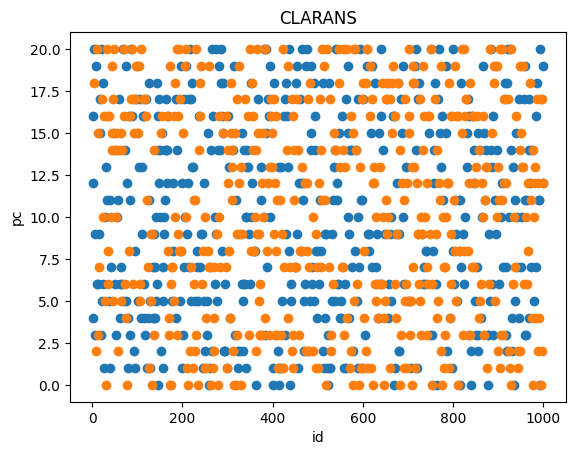

In [ ]:
for cluster in range(num_clusters):
    cluster_data = data_with_clusters[data_with_clusters['Cluster'] == cluster]
    plt.scatter(cluster_data.id, cluster_data['pc'], label=f'Cluster {cluster}')
plt.xlabel('id')
plt.ylabel('pc')
plt.title('CLARANS')
plt.show()

# **Đánh giá gom cụm**

In [ ]:
from sklearn.metrics import silhouette_score

[0.3433194610257367, 0.24740560842344866, 0.17845605751567153, 0.19181331688419323, 0.1200069348210881, 0.17226441596592587, 0.13406813626510752, 0.14072580075780133, 0.07675764960276542]


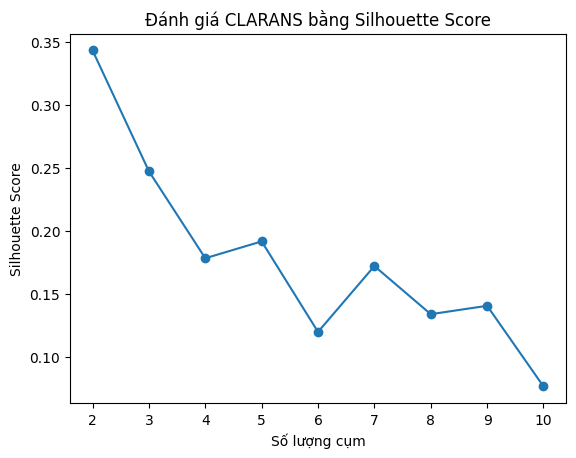

In [ ]:
import matplotlib.pyplot as plt

def evaluate_clarans_clustering(data, num_clusters_range, max_neighbor, num_local):
    silhouette_scores = []

    for num_clusters in num_clusters_range:
        silhouette_avg = evaluate_clarans_clustering_single(data, num_clusters, max_neighbor, num_local)
        silhouette_scores.append(silhouette_avg)

    return silhouette_scores

def evaluate_clarans_clustering_single(data, num_clusters, max_neighbor, num_local):
    # Khởi tạo và fit thuật toán CLARANS
    clarans = CLARANS(data=data, num_clusters=num_clusters, max_neighbor=max_neighbor, num_local=num_local)
    labels = clarans.fit()

    # Tính toán Silhouette Score
    silhouette_avg = silhouette_score(data, labels)
    return silhouette_avg

# Thiết lập các tham số
num_clusters_range = range(2, 11)
max_neighbor = 6
num_local = 2

# Đánh giá gom cụm bằng Silhouette Score
silhouette_scores = evaluate_clarans_clustering(data_array, num_clusters_range, max_neighbor, num_local)

print(silhouette_scores)
# Vẽ biểu đồ
plt.plot(num_clusters_range, silhouette_scores, marker='o')
plt.xlabel('Số lượng cụm')
plt.ylabel('Silhouette Score')
plt.title('Đánh giá CLARANS bằng Silhouette Score')

# Hiển thị biểu đồ
plt.show()